# Hourly Shift Model Prototype

This notebook starts a clean prototype for household load shifting using only the price forecasts from `XG_Boost_full_Res.py`.

Scope of this prototype:
- use the saved XGBoost `120` hour point forecasts
- combine them with hourly DK1 consumption context
- define simple household segments
- run one transparent first-pass shifting heuristic
- inspect the resulting cost and load-shift effects step by step


## Prototype Notes

This is intentionally not built on the existing simulation scripts.

It uses:
- `outputs/model/predictions.parquet` from `XG_Boost_full_Res.py`
- `data/consumption_dk1_raw.csv`
The first version uses a simple heuristic decision rule so we can see the mechanics clearly before moving to a full optimization model.


In [196]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

ROOT = Path.cwd()
PRED_PATH = ROOT / "outputs" / "model" / "predictions.parquet"
CONSUMPTION_PATH = ROOT / "data" / "consumption_dk1_raw.csv"
HOUSEHOLD_SHARE_OF_SYSTEM = 0.33
ROLLING_BACKTEST_MAX_WINDOWS = 120
ANNUAL_HEATMAP_DAILY_ISSUES = 365

SEGMENT_COLORS = {
    "inflexible": "#B0BEC5",
    "wet_loads": "#1E88E5",
    "thermal": "#43A047",
    "ev": "#FB8C00",
}

SEGMENT_ASSUMPTIONS = {
    "inflexible": {
        "share_of_household_load": 0.60,
        "max_shiftable_share": 0.00,
        "max_wait_h": 0,
        "wait_penalty": 0.00,
    },
    "wet_loads": {
        "share_of_household_load": 0.10,
        "max_shiftable_share": 0.55,
        "max_wait_h": 24*2,
        "wait_penalty": 0.90,
    },
    "thermal": {
        "share_of_household_load": 0.20,
        "max_shiftable_share": 0.25,
        "max_wait_h": 24*1,
        "wait_penalty": 1.20,
    },
    "ev": {
        "share_of_household_load": 0.10,
        "max_shiftable_share": 0.85,
        "max_wait_h": 24*4,
        "wait_penalty": 0.35,
    },
}

DECISION_WEIGHTS = {
    "price": 0.80,
    "wait": 0.20,
}

sum(v["share_of_household_load"] for v in SEGMENT_ASSUMPTIONS.values())


1.0

In [197]:
preds = pd.read_parquet(PRED_PATH)
preds["issue_time"] = pd.to_datetime(preds["issue_time"])
preds["target_time"] = pd.to_datetime(preds["target_time"])
preds["fold_end"] = pd.to_datetime(preds["fold_end"])
preds = preds.sort_values(["fold", "issue_time", "horizon_h"]).reset_index(drop=True)

coverage = (
    preds.groupby(["fold", "issue_time"], as_index=False)
    .agg(
        horizons=("horizon_h", "nunique"),
        min_h=("horizon_h", "min"),
        max_h=("horizon_h", "max"),
    )
)
full_coverage = coverage[(coverage["horizons"] == 120) & (coverage["min_h"] == 1) & (coverage["max_h"] == 120)].copy()
selected_issue_time = full_coverage.sort_values("issue_time").iloc[-1]["issue_time"]

forecast_window = (
    preds[preds["issue_time"] == selected_issue_time]
    .sort_values("horizon_h")
    .reset_index(drop=True)
)

print(f"Selected issue time: {selected_issue_time}")
print(f"Forecast window rows: {len(forecast_window)}")
display(forecast_window.head())
display(forecast_window.tail())


Selected issue time: 2025-12-31 12:00:00
Forecast window rows: 120


,issue_time,target_time,horizon_h,DayAheadPriceEUR,predicted,fold,fold_end
0,2025-12-31 12:00:00,2025-12-31 13:00:00,1,85.170000,90.890129,11,2025-10-01
1,2025-12-31 12:00:00,2025-12-31 14:00:00,2,85.177500,93.082664,11,2025-10-01
2,2025-12-31 12:00:00,2025-12-31 15:00:00,3,90.832498,98.224121,11,2025-10-01
3,2025-12-31 12:00:00,2025-12-31 16:00:00,4,100.705002,105.485001,11,2025-10-01
4,2025-12-31 12:00:00,2025-12-31 17:00:00,5,110.099999,121.796593,11,2025-10-01


,issue_time,target_time,horizon_h,DayAheadPriceEUR,predicted,fold,fold_end
115,2025-12-31 12:00:00,2026-01-05 08:00:00,116,151.175003,127.366325,11,2025-10-01
116,2025-12-31 12:00:00,2026-01-05 09:00:00,117,152.150001,115.103996,11,2025-10-01
117,2025-12-31 12:00:00,2026-01-05 10:00:00,118,145.637505,129.186508,11,2025-10-01
118,2025-12-31 12:00:00,2026-01-05 11:00:00,119,136.702499,115.521545,11,2025-10-01
119,2025-12-31 12:00:00,2026-01-05 12:00:00,120,134.432503,107.595734,11,2025-10-01


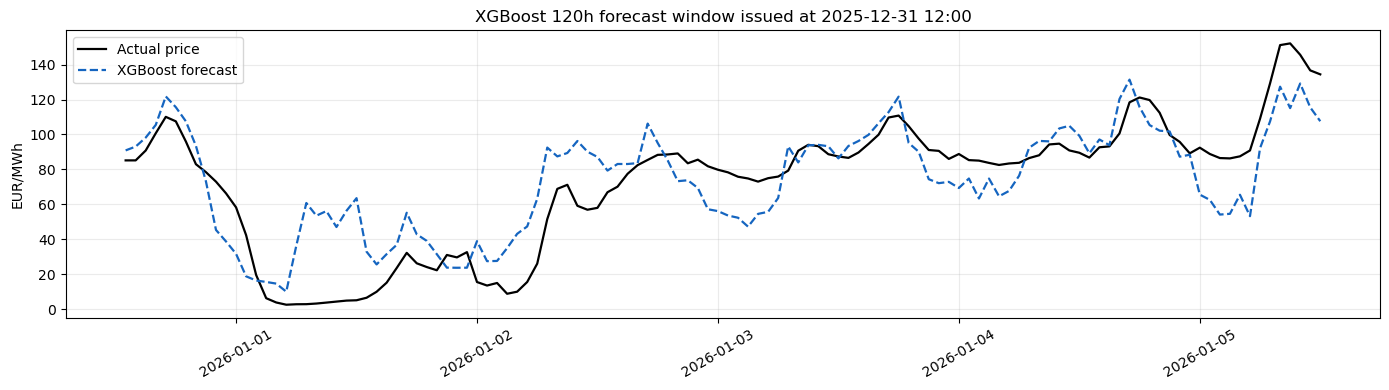

In [198]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(forecast_window["target_time"], forecast_window["DayAheadPriceEUR"], label="Actual price", color="black", linewidth=1.6)
ax.plot(forecast_window["target_time"], forecast_window["predicted"], label="XGBoost forecast", color="#1565C0", linewidth=1.6, linestyle="--")
ax.set_title(f"XGBoost 120h forecast window issued at {selected_issue_time:%Y-%m-%d %H:%M}")
ax.set_ylabel("EUR/MWh")
ax.grid(alpha=0.25)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()


In [199]:
consumption = pd.read_csv(CONSUMPTION_PATH, parse_dates=["TimeDK"])
system_load = (
    consumption.groupby(pd.Grouper(key="TimeDK", freq="h"))["ConsumptionkWh"]
    .sum()
    .div(1000.0)
    .rename("system_load_mwh")
    .reset_index()
    .rename(columns={"TimeDK": "target_time"})
)
historical_segment_capacity = system_load[["target_time", "system_load_mwh"]].copy()
historical_segment_capacity["household_load_mwh"] = historical_segment_capacity["system_load_mwh"] * HOUSEHOLD_SHARE_OF_SYSTEM
for segment, params in SEGMENT_ASSUMPTIONS.items():
    segment_cap_col = f"{segment}_historical_cap_mwh"
    historical_segment_capacity[segment_cap_col] = (
        historical_segment_capacity["household_load_mwh"] * params["share_of_household_load"]
    )

historical_segment_capacity = (
    historical_segment_capacity[
        [f"{segment}_historical_cap_mwh" for segment in SEGMENT_ASSUMPTIONS]
    ]
    .max()
    .to_frame()
    .T
)

window_df = forecast_window.merge(system_load, on="target_time", how="left")
window_df["system_load_mwh"] = window_df["system_load_mwh"].ffill().bfill()
window_df["household_load_mwh"] = window_df["system_load_mwh"] * HOUSEHOLD_SHARE_OF_SYSTEM

display(window_df[["target_time", "horizon_h", "predicted", "DayAheadPriceEUR", "system_load_mwh", "household_load_mwh"]].head())


,target_time,horizon_h,predicted,DayAheadPriceEUR,system_load_mwh,household_load_mwh
0,2025-12-31 13:00:00,1,90.890129,85.170000,2723.044591,898.604715
1,2025-12-31 14:00:00,2,93.082664,85.177500,2614.115651,862.658165
2,2025-12-31 15:00:00,3,98.224121,90.832498,2660.063258,877.820875
3,2025-12-31 16:00:00,4,105.485001,100.705002,2788.393626,920.169897
4,2025-12-31 17:00:00,5,121.796593,110.099999,2872.311541,947.862809


In [200]:
display(window_df[["target_time", "system_load_mwh", "household_load_mwh"]].head())


,target_time,system_load_mwh,household_load_mwh
0,2025-12-31 13:00:00,2723.044591,898.604715
1,2025-12-31 14:00:00,2614.115651,862.658165
2,2025-12-31 15:00:00,2660.063258,877.820875
3,2025-12-31 16:00:00,2788.393626,920.169897
4,2025-12-31 17:00:00,2872.311541,947.862809


In [201]:
segment_table = pd.DataFrame(SEGMENT_ASSUMPTIONS).T
segment_table.index.name = "segment"
display(segment_table)

for segment, params in SEGMENT_ASSUMPTIONS.items():
    base_col = f"{segment}_baseline_mwh"
    flex_col = f"{segment}_flexible_mwh"
    window_df[base_col] = window_df["household_load_mwh"] * params["share_of_household_load"]
    window_df[flex_col] = window_df[base_col] * params["max_shiftable_share"]

base_cols = [f"{segment}_baseline_mwh" for segment in SEGMENT_ASSUMPTIONS]
window_df["baseline_household_check_mwh"] = window_df[base_cols].sum(axis=1)
window_df[["target_time", "household_load_mwh", "baseline_household_check_mwh"]].head()


,share_of_household_load,max_shiftable_share,max_wait_h,wait_penalty
segment,,,,
inflexible,0.6,0.00,0.0,0.00
wet_loads,0.1,0.55,48.0,0.90
thermal,0.2,0.25,24.0,1.20
ev,0.1,0.85,96.0,0.35


,target_time,household_load_mwh,baseline_household_check_mwh
0,2025-12-31 13:00:00,898.604715,898.604715
1,2025-12-31 14:00:00,862.658165,862.658165
2,2025-12-31 15:00:00,877.820875,877.820875
3,2025-12-31 16:00:00,920.169897,920.169897
4,2025-12-31 17:00:00,947.862809,947.862809


In [202]:
def _normalize(series: pd.Series) -> pd.Series:
    s_min = float(series.min())
    s_max = float(series.max())
    if np.isclose(s_min, s_max):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - s_min) / (s_max - s_min)


def build_shift_plan(
    window_df: pd.DataFrame,
    segment_assumptions: dict,
    decision_weights: dict,
    historical_segment_capacity: pd.DataFrame,
):
    df = window_df.copy().reset_index(drop=True)
    df["other_system_load_mwh"] = df["system_load_mwh"] - df["household_load_mwh"]

    shift_rows = []
    shifted_cols = []

    for segment, params in segment_assumptions.items():
        base_col = f"{segment}_baseline_mwh"
        flex_col = f"{segment}_flexible_mwh"
        cap_col = f"{segment}_historical_cap_mwh"
        shifted = df[base_col].to_numpy(dtype=float).copy()
        # Historical segment-cap rule: a segment can only move into a target hour
        # up to the maximum amount historically observed for that segment across all hours.
        segment_capacity_value = float(historical_segment_capacity.iloc[0][cap_col])
        segment_capacity = np.full(len(df), segment_capacity_value, dtype=float)
        flexible = df[flex_col].to_numpy(dtype=float)

        if params["max_shiftable_share"] == 0 or params["max_wait_h"] == 0:
            df[f"{segment}_shifted_mwh"] = shifted
            shifted_cols.append(f"{segment}_shifted_mwh")
            continue

        for origin in range(len(df)):
            movable = flexible[origin]
            if movable <= 0:
                continue

            max_wait = int(params["max_wait_h"])
            end = min(len(df) - 1, origin + max_wait)
            candidates = df.loc[origin:end, ["target_time", "predicted"]].copy()
            candidates["wait_h"] = np.arange(len(candidates))
            candidates["price_norm"] = _normalize(candidates["predicted"])
            candidates["wait_norm"] = candidates["wait_h"] / max(max_wait, 1)

            candidates["score"] = (
                decision_weights["price"] * candidates["price_norm"]
                + decision_weights["wait"] * params["wait_penalty"] * candidates["wait_norm"]
            )

            origin_score = float(candidates.iloc[0]["score"])
            ranked_candidate_indices = candidates.sort_values("score").index.tolist()
            remaining_movable = movable

            for rank_position, candidate_idx in enumerate(ranked_candidate_indices, start=1):
                candidate_idx = int(candidate_idx)
                if candidate_idx == origin:
                    continue
                candidate_score = float(candidates.loc[candidate_idx, "score"])
                if candidate_score >= origin_score:
                    continue
                available_room = segment_capacity[candidate_idx] - shifted[candidate_idx]
                if available_room <= 0:
                    continue

                allocated_mwh = min(remaining_movable, available_room)
                if allocated_mwh <= 0:
                    continue

                score_gain = origin_score - candidate_score
                projected_target_segment_load = shifted[candidate_idx] + allocated_mwh

                shifted[origin] -= allocated_mwh
                shifted[candidate_idx] += allocated_mwh
                remaining_movable -= allocated_mwh

                shift_rows.append(
                    {
                        "segment": segment,
                        "origin_index": origin,
                        "target_index": candidate_idx,
                        "origin_time": df.loc[origin, "target_time"],
                        "target_time": df.loc[candidate_idx, "target_time"],
                        "wait_h": candidate_idx - origin,
                        "shift_mwh": allocated_mwh,
                        "origin_predicted_price": df.loc[origin, "predicted"],
                        "target_predicted_price": df.loc[candidate_idx, "predicted"],
                        "score_gain": score_gain,
                        "chosen_rank": rank_position,
                        "target_segment_capacity_mwh": segment_capacity[candidate_idx],
                        "available_room_before_allocation_mwh": available_room,
                        "projected_target_segment_load_mwh": projected_target_segment_load,
                        "remaining_origin_movable_mwh": remaining_movable,
                    }
                )

                if remaining_movable <= 1e-9:
                    break

        shifted_col = f"{segment}_shifted_mwh"
        df[shifted_col] = shifted
        shifted_cols.append(shifted_col)

    df["shifted_household_load_mwh"] = df[shifted_cols].sum(axis=1)
    df["shifted_system_load_mwh"] = df["other_system_load_mwh"] + df["shifted_household_load_mwh"]
    df["baseline_household_cost_eur"] = df["household_load_mwh"] * df["DayAheadPriceEUR"]
    df["shifted_household_cost_eur"] = df["shifted_household_load_mwh"] * df["DayAheadPriceEUR"]
    df["baseline_predicted_cost_eur"] = df["household_load_mwh"] * df["predicted"]
    df["shifted_predicted_cost_eur"] = df["shifted_household_load_mwh"] * df["predicted"]

    shifts = pd.DataFrame(
        shift_rows,
        columns=[
            "segment",
            "origin_index",
            "target_index",
            "origin_time",
            "target_time",
            "wait_h",
            "shift_mwh",
            "origin_predicted_price",
            "target_predicted_price",
            "score_gain",
            "chosen_rank",
            "target_segment_capacity_mwh",
            "available_room_before_allocation_mwh",
            "projected_target_segment_load_mwh",
            "remaining_origin_movable_mwh",
        ],
    )
    return df, shifts


In [203]:
prototype_df, shifts_df = build_shift_plan(
    window_df,
    SEGMENT_ASSUMPTIONS,
    DECISION_WEIGHTS,
    historical_segment_capacity,
)

selected_shifted_energy_mwh = float(shifts_df["shift_mwh"].sum()) if not shifts_df.empty else 0.0
selected_total_system_consumption_mwh = float(prototype_df["system_load_mwh"].sum())
selected_total_household_consumption_mwh = float(prototype_df["household_load_mwh"].sum())

summary = pd.Series(
    {
        "selected_issue_time": selected_issue_time,
        "horizon_hours": len(prototype_df),
        "n_shift_events": int(len(shifts_df)),
        "shifted_energy_mwh": selected_shifted_energy_mwh,
        "modeled_total_system_consumption_mwh": selected_total_system_consumption_mwh,
        "modeled_total_household_consumption_mwh": selected_total_household_consumption_mwh,
        "shifted_share_of_system_consumption_pct": 100.0 * selected_shifted_energy_mwh / selected_total_system_consumption_mwh,
        "shifted_share_of_household_consumption_pct": 100.0 * selected_shifted_energy_mwh / selected_total_household_consumption_mwh,
        "realized_household_savings_eur": float(prototype_df["baseline_household_cost_eur"].sum() - prototype_df["shifted_household_cost_eur"].sum()),
        "predicted_household_savings_eur": float(prototype_df["baseline_predicted_cost_eur"].sum() - prototype_df["shifted_predicted_cost_eur"].sum()),
    }
)


display(summary.to_frame("value"))
display(shifts_df.sort_values("shift_mwh", ascending=False).head(20))
display(historical_segment_capacity)


,value
selected_issue_time,2025-12-31 12:00:00
horizon_hours,120
n_shift_events,330
shifted_energy_mwh,9852.760881
modeled_total_system_consumption_mwh,370418.631059
modeled_total_household_consumption_mwh,122238.148249
shifted_share_of_system_consumption_pct,2.659899
shifted_share_of_household_consumption_pct,8.0603
baseline_peak_mwh,3799.688392
shifted_peak_mwh,3821.125892


,segment,origin_index,target_index,origin_time,target_time,wait_h,shift_mwh,origin_predicted_price,target_predicted_price,score_gain,chosen_rank,target_segment_capacity_mwh,available_room_before_allocation_mwh,projected_target_segment_load_mwh,remaining_origin_movable_mwh
262,ev,41,64,2026-01-02 06:00:00,2026-01-03 05:00:00,23,63.290833,63.203648,55.731472,0.054245,5,146.845297,63.290833,146.845297,20.082275
282,ev,48,88,2026-01-02 13:00:00,2026-01-04 05:00:00,40,59.272012,79.341026,67.691254,0.081553,18,146.845297,59.272012,146.845297,11.444603
276,ev,46,87,2026-01-02 11:00:00,2026-01-04 04:00:00,41,57.805162,90.159821,64.604225,0.212984,14,146.845297,57.805162,146.845297,23.462162
290,ev,51,82,2026-01-02 16:00:00,2026-01-03 23:00:00,31,57.438325,83.615082,72.878487,0.079436,23,146.845297,57.438325,146.845297,14.812491
141,thermal,27,31,2026-01-01 16:00:00,2026-01-01 20:00:00,4,56.727878,36.819836,31.453215,0.019158,4,293.690594,88.761695,261.656777,0.000000
39,wet_loads,41,62,2026-01-02 06:00:00,2026-01-03 03:00:00,21,56.508768,63.203648,47.234329,0.092890,1,146.845297,56.508768,146.845297,0.246321
255,ev,20,62,2026-01-01 09:00:00,2026-01-03 03:00:00,42,56.508768,56.167385,47.234329,0.035729,18,146.845297,56.508768,146.845297,1.163567
146,thermal,30,37,2026-01-01 19:00:00,2026-01-02 02:00:00,7,56.508756,39.067642,27.602230,0.041142,6,293.690594,84.631717,265.567633,0.000000
307,ev,73,90,2026-01-03 14:00:00,2026-01-04 07:00:00,17,56.413691,96.268791,92.416710,0.027024,21,146.845297,56.413691,146.845297,28.350092
156,thermal,46,60,2026-01-02 11:00:00,2026-01-03 01:00:00,14,56.348099,90.159821,53.609085,0.355589,3,293.690594,68.536772,281.501922,0.000000


,inflexible_historical_cap_mwh,wet_loads_historical_cap_mwh,thermal_historical_cap_mwh,ev_historical_cap_mwh
0,881.071783,146.845297,293.690594,146.845297


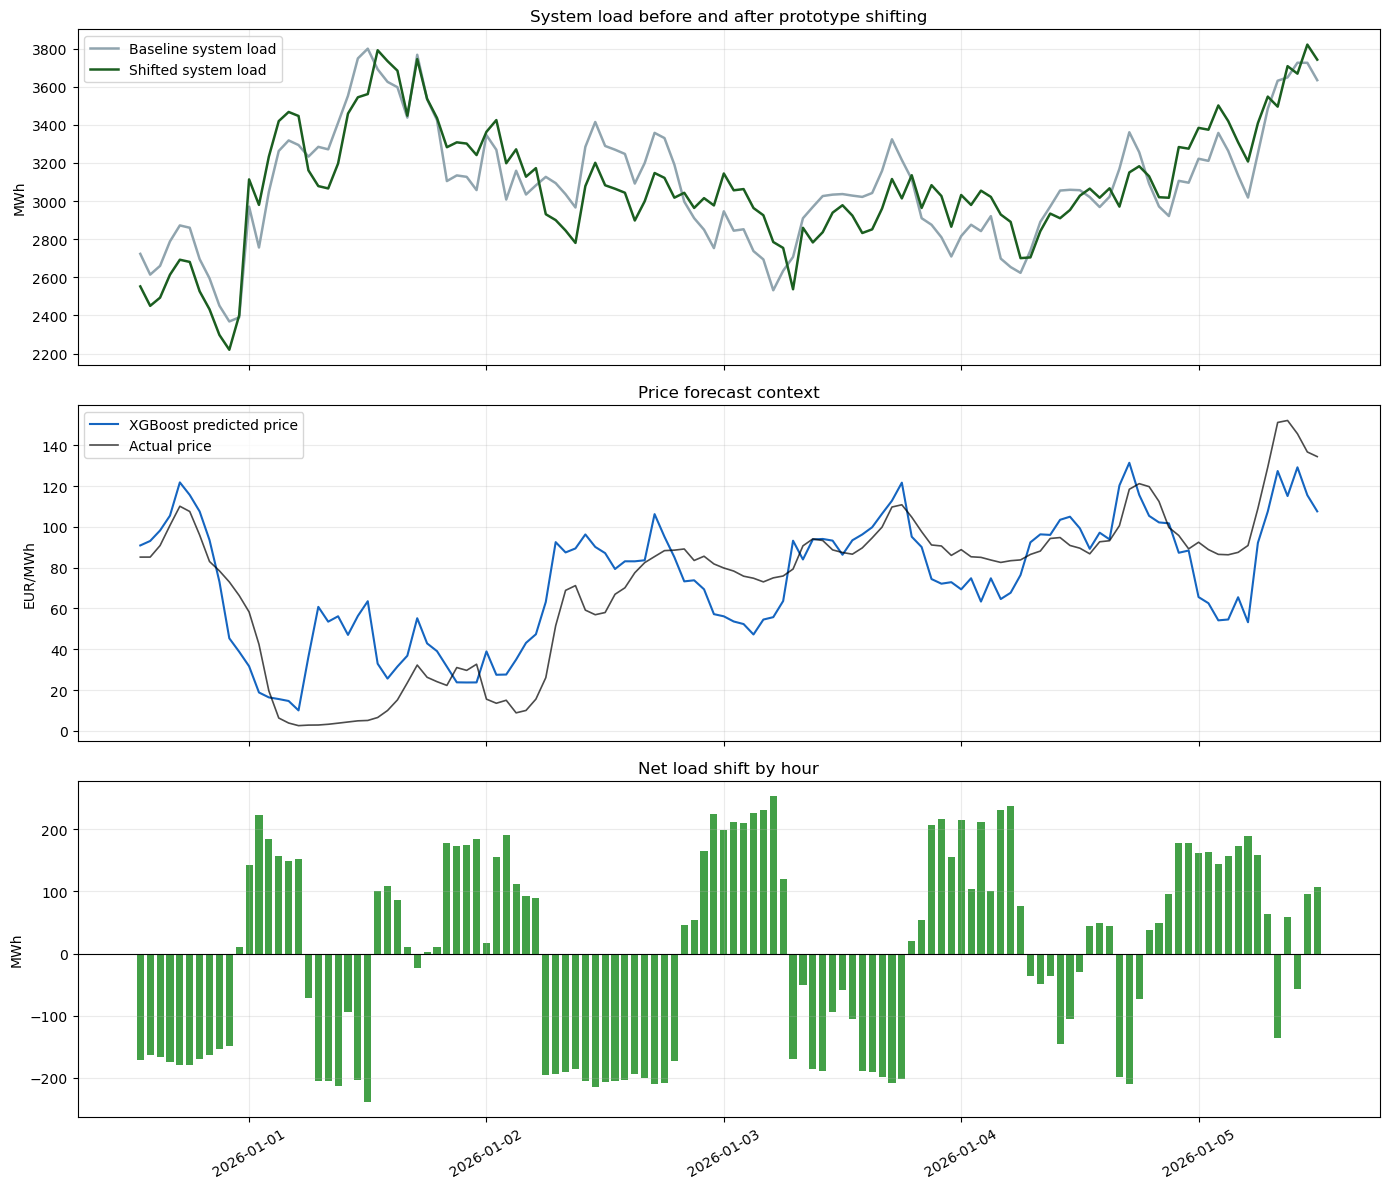

In [204]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(prototype_df["target_time"], prototype_df["system_load_mwh"], label="Baseline system load", color="#90A4AE", linewidth=1.8)
axes[0].plot(prototype_df["target_time"], prototype_df["shifted_system_load_mwh"], label="Shifted system load", color="#1B5E20", linewidth=1.8)
axes[0].set_ylabel("MWh")
axes[0].set_title("System load before and after prototype shifting")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(prototype_df["target_time"], prototype_df["predicted"], label="XGBoost predicted price", color="#1565C0", linewidth=1.5)
axes[1].plot(prototype_df["target_time"], prototype_df["DayAheadPriceEUR"], label="Actual price", color="black", linewidth=1.2, alpha=0.7)
axes[1].set_ylabel("EUR/MWh")
axes[1].set_title("Price forecast context")
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].bar(prototype_df["target_time"], prototype_df["shifted_system_load_mwh"] - prototype_df["system_load_mwh"], width=0.03, color="#43A047")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_ylabel("MWh")
axes[2].set_title("Net load shift by hour")
axes[2].grid(alpha=0.25)

plt.xticks(rotation=30)
plt.tight_layout()


## Rolling Backtest Setup

The single-window prototype is useful for inspection, but the next step is to test the heuristic over many historical XGBoost forecast issue times.

Two views are useful:
- a `daily` rolling backtest at `12:00` issue times to see stability over time
- a `non-overlapping` subset sampled every `5` days so total shifted MWh can be compared cleanly with total modeled consumption without double-counting overlapping horizons


In [205]:
def assemble_window_for_issue_time(
    issue_time: pd.Timestamp,
    preds: pd.DataFrame,
    system_load: pd.DataFrame,
    household_share_of_system: float,
    segment_assumptions: dict,
) -> pd.DataFrame:
    issue_time = pd.Timestamp(issue_time)
    forecast_window = (
        preds[preds["issue_time"] == issue_time]
        .sort_values("horizon_h")
        .reset_index(drop=True)
    )
    if len(forecast_window) != 120:
        raise ValueError(f"Issue time {issue_time} does not have a full 120h forecast window.")

    window_df = forecast_window.merge(system_load, on="target_time", how="left")
    window_df["system_load_mwh"] = window_df["system_load_mwh"].ffill().bfill()
    window_df["household_load_mwh"] = window_df["system_load_mwh"] * household_share_of_system

    for segment, params in segment_assumptions.items():
        base_col = f"{segment}_baseline_mwh"
        flex_col = f"{segment}_flexible_mwh"
        window_df[base_col] = window_df["household_load_mwh"] * params["share_of_household_load"]
        window_df[flex_col] = window_df[base_col] * params["max_shiftable_share"]

    return window_df


def summarize_issue_time_run(
    issue_time: pd.Timestamp,
    preds: pd.DataFrame,
    system_load: pd.DataFrame,
    household_share_of_system: float,
    segment_assumptions: dict,
    decision_weights: dict,
    historical_segment_capacity: pd.DataFrame,
) -> dict:
    window_df = assemble_window_for_issue_time(
        issue_time=issue_time,
        preds=preds,
        system_load=system_load,
        household_share_of_system=household_share_of_system,
        segment_assumptions=segment_assumptions,
    )
    prototype_df, shifts_df = build_shift_plan(
        window_df,
        segment_assumptions,
        decision_weights,
        historical_segment_capacity,
    )

    shifted_energy_mwh = float(shifts_df["shift_mwh"].sum()) if not shifts_df.empty else 0.0
    total_system_consumption_mwh = float(prototype_df["system_load_mwh"].sum())
    total_household_consumption_mwh = float(prototype_df["household_load_mwh"].sum())

    return {
        "issue_time": pd.Timestamp(issue_time),
        "horizon_hours": int(len(prototype_df)),
        "n_shift_events": int(len(shifts_df)),
        "shifted_energy_mwh": shifted_energy_mwh,
        "modeled_total_system_consumption_mwh": total_system_consumption_mwh,
        "modeled_total_household_consumption_mwh": total_household_consumption_mwh,
        "shifted_share_of_system_consumption_pct": 100.0 * shifted_energy_mwh / total_system_consumption_mwh,
        "shifted_share_of_household_consumption_pct": 100.0 * shifted_energy_mwh / total_household_consumption_mwh,
        "realized_household_savings_eur": float(prototype_df["baseline_household_cost_eur"].sum() - prototype_df["shifted_household_cost_eur"].sum()),
        "predicted_household_savings_eur": float(prototype_df["baseline_predicted_cost_eur"].sum() - prototype_df["shifted_predicted_cost_eur"].sum()),
    }


In [206]:
issue_catalog = full_coverage.sort_values("issue_time").reset_index(drop=True)
daily_issue_times = issue_catalog.loc[issue_catalog["issue_time"].dt.hour == 12, "issue_time"].reset_index(drop=True)
backtest_issue_times = daily_issue_times.tail(ROLLING_BACKTEST_MAX_WINDOWS).reset_index(drop=True)
non_overlapping_issue_times = backtest_issue_times.iloc[::5].reset_index(drop=True)

display(
    pd.Series(
        {
            "available_full_120h_issue_times": int(len(issue_catalog)),
            "available_daily_12h_issue_times": int(len(daily_issue_times)),
            "rolling_backtest_daily_windows": int(len(backtest_issue_times)),
            "non_overlapping_5day_windows": int(len(non_overlapping_issue_times)),
        }
    ).to_frame("value")
)


,value
available_full_120h_issue_times,2162
available_daily_12h_issue_times,1081
rolling_backtest_daily_windows,120
non_overlapping_5day_windows,24


In [207]:
rolling_backtest_df = pd.DataFrame(
    [
        summarize_issue_time_run(
            issue_time=issue_time,
            preds=preds,
            system_load=system_load,
            household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
            segment_assumptions=SEGMENT_ASSUMPTIONS,
            decision_weights=DECISION_WEIGHTS,
            historical_segment_capacity=historical_segment_capacity,
        )
        for issue_time in backtest_issue_times
    ]
)

non_overlapping_backtest_df = rolling_backtest_df[
    rolling_backtest_df["issue_time"].isin(non_overlapping_issue_times)
].copy()

display(rolling_backtest_df.head())


,issue_time,horizon_hours,n_shift_events,shifted_energy_mwh,modeled_total_system_consumption_mwh,modeled_total_household_consumption_mwh,shifted_share_of_system_consumption_pct,shifted_share_of_household_consumption_pct,baseline_peak_mwh,shifted_peak_mwh,peak_reduction_mwh,realized_household_savings_eur,predicted_household_savings_eur
0,2025-09-03 12:00:00,120,341,10236.772227,286822.151449,94651.309978,3.569031,10.815246,3287.416287,3436.424586,-149.008299,544325.007202,441816.641394
1,2025-09-04 12:00:00,120,339,9850.116749,281072.875098,92754.048782,3.504471,10.619608,3282.308062,3354.723409,-72.415347,633852.339235,491420.075152
2,2025-09-05 12:00:00,120,329,9629.548270,281616.542155,92933.458911,3.419383,10.361767,3188.182282,3354.723409,-166.541127,648121.399658,501834.140844
3,2025-09-06 12:00:00,120,332,9851.935120,290700.285185,95931.094111,3.389035,10.269804,3485.105399,3612.452675,-127.347276,580179.797204,437927.366525
4,2025-09-07 12:00:00,120,319,9480.365877,303970.574901,100310.289717,3.118843,9.451040,3560.867521,3678.214197,-117.346676,665254.173536,461490.876154


## Rolling Backtest Summary

The daily backtest shows how stable the prototype is over time. The non-overlapping summary is the cleanest answer to the question "how much MWh did we shift relative to the total consumption we modeled?" because it avoids counting overlapping 120-hour horizons multiple times.


In [208]:
rolling_summary = pd.Series(
    {
        "daily_windows_evaluated": int(len(rolling_backtest_df)),
        "avg_shifted_energy_mwh_per_120h_window": float(rolling_backtest_df["shifted_energy_mwh"].mean()),
        "median_shifted_energy_mwh_per_120h_window": float(rolling_backtest_df["shifted_energy_mwh"].median()),
        "avg_shifted_share_of_system_consumption_pct": float(rolling_backtest_df["shifted_share_of_system_consumption_pct"].mean()),
        "avg_shifted_share_of_household_consumption_pct": float(rolling_backtest_df["shifted_share_of_household_consumption_pct"].mean()),
        "avg_realized_household_savings_eur": float(rolling_backtest_df["realized_household_savings_eur"].mean()),
    }
)

non_overlapping_summary = pd.Series(
    {
        "non_overlapping_120h_windows": int(len(non_overlapping_backtest_df)),
        "total_shifted_energy_mwh": float(non_overlapping_backtest_df["shifted_energy_mwh"].sum()),
        "total_modeled_system_consumption_mwh": float(non_overlapping_backtest_df["modeled_total_system_consumption_mwh"].sum()),
        "total_modeled_household_consumption_mwh": float(non_overlapping_backtest_df["modeled_total_household_consumption_mwh"].sum()),
        "shifted_share_of_total_modeled_system_consumption_pct": 100.0 * float(non_overlapping_backtest_df["shifted_energy_mwh"].sum()) / float(non_overlapping_backtest_df["modeled_total_system_consumption_mwh"].sum()),
        "shifted_share_of_total_modeled_household_consumption_pct": 100.0 * float(non_overlapping_backtest_df["shifted_energy_mwh"].sum()) / float(non_overlapping_backtest_df["modeled_total_household_consumption_mwh"].sum()),
        "total_realized_household_savings_eur": float(non_overlapping_backtest_df["realized_household_savings_eur"].sum()),
    }
)

display(rolling_summary.to_frame("value"))
display(non_overlapping_summary.to_frame("value"))


,value
daily_windows_evaluated,120.000000
avg_shifted_energy_mwh_per_120h_window,10426.855905
median_shifted_energy_mwh_per_120h_window,10406.928524
avg_shifted_share_of_system_consumption_pct,3.151863
avg_shifted_share_of_household_consumption_pct,9.551101
avg_realized_household_savings_eur,356343.112013
avg_peak_reduction_mwh,-63.782739


,value
non_overlapping_120h_windows,2.400000e+01
total_shifted_energy_mwh,2.513665e+05
total_modeled_system_consumption_mwh,7.944184e+06
total_modeled_household_consumption_mwh,2.621581e+06
shifted_share_of_total_modeled_system_consumption_pct,3.164157e+00
shifted_share_of_total_modeled_household_consumption_pct,9.588355e+00
total_realized_household_savings_eur,8.249690e+06


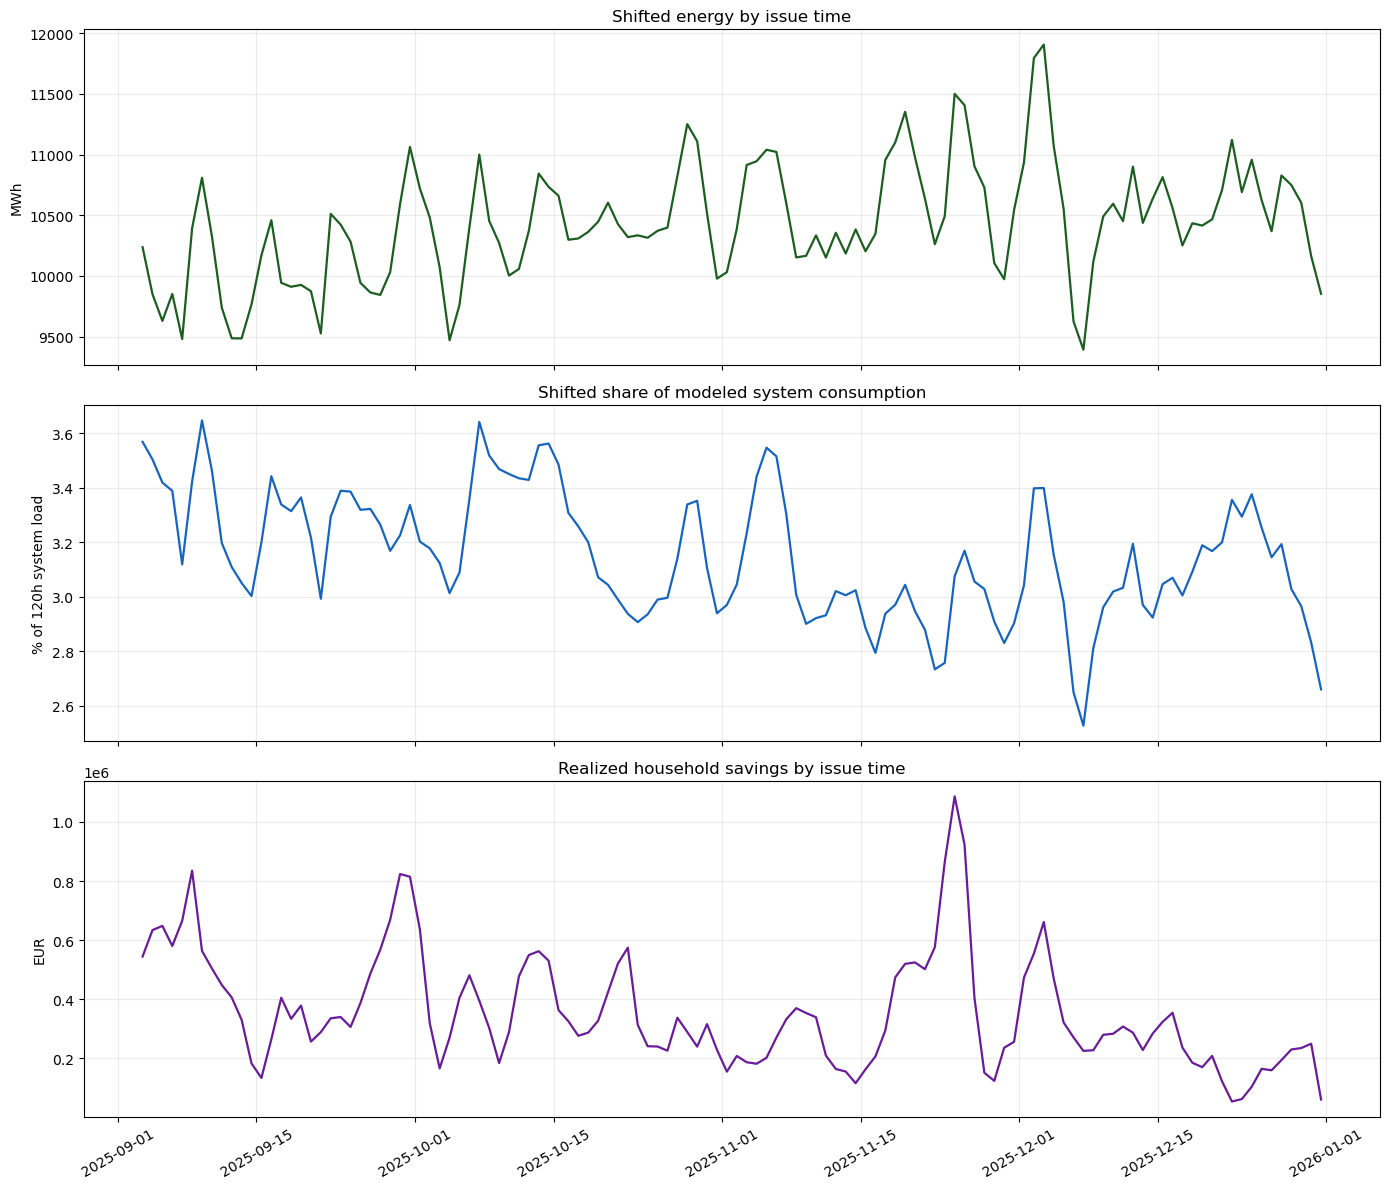

In [209]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(rolling_backtest_df["issue_time"], rolling_backtest_df["shifted_energy_mwh"], color="#1B5E20", linewidth=1.6)
axes[0].set_title("Shifted energy by issue time")
axes[0].set_ylabel("MWh")
axes[0].grid(alpha=0.25)

axes[1].plot(rolling_backtest_df["issue_time"], rolling_backtest_df["shifted_share_of_system_consumption_pct"], color="#1565C0", linewidth=1.6)
axes[1].set_title("Shifted share of modeled system consumption")
axes[1].set_ylabel("% of 120h system load")
axes[1].grid(alpha=0.25)

axes[2].plot(rolling_backtest_df["issue_time"], rolling_backtest_df["realized_household_savings_eur"], color="#6A1B9A", linewidth=1.6)
axes[2].set_title("Realized household savings by issue time")
axes[2].set_ylabel("EUR")
axes[2].grid(alpha=0.25)

plt.xticks(rotation=30)
plt.tight_layout()


## Granular Shift Illustration

The next views give a more detailed picture of how the heuristic moves load:
- an hour-by-hour detail view for the selected `120h` window
- a stacked segment view of shifted household energy hour by hour
- an average net-shift heatmap by day of week and hour of day across the rolling backtest


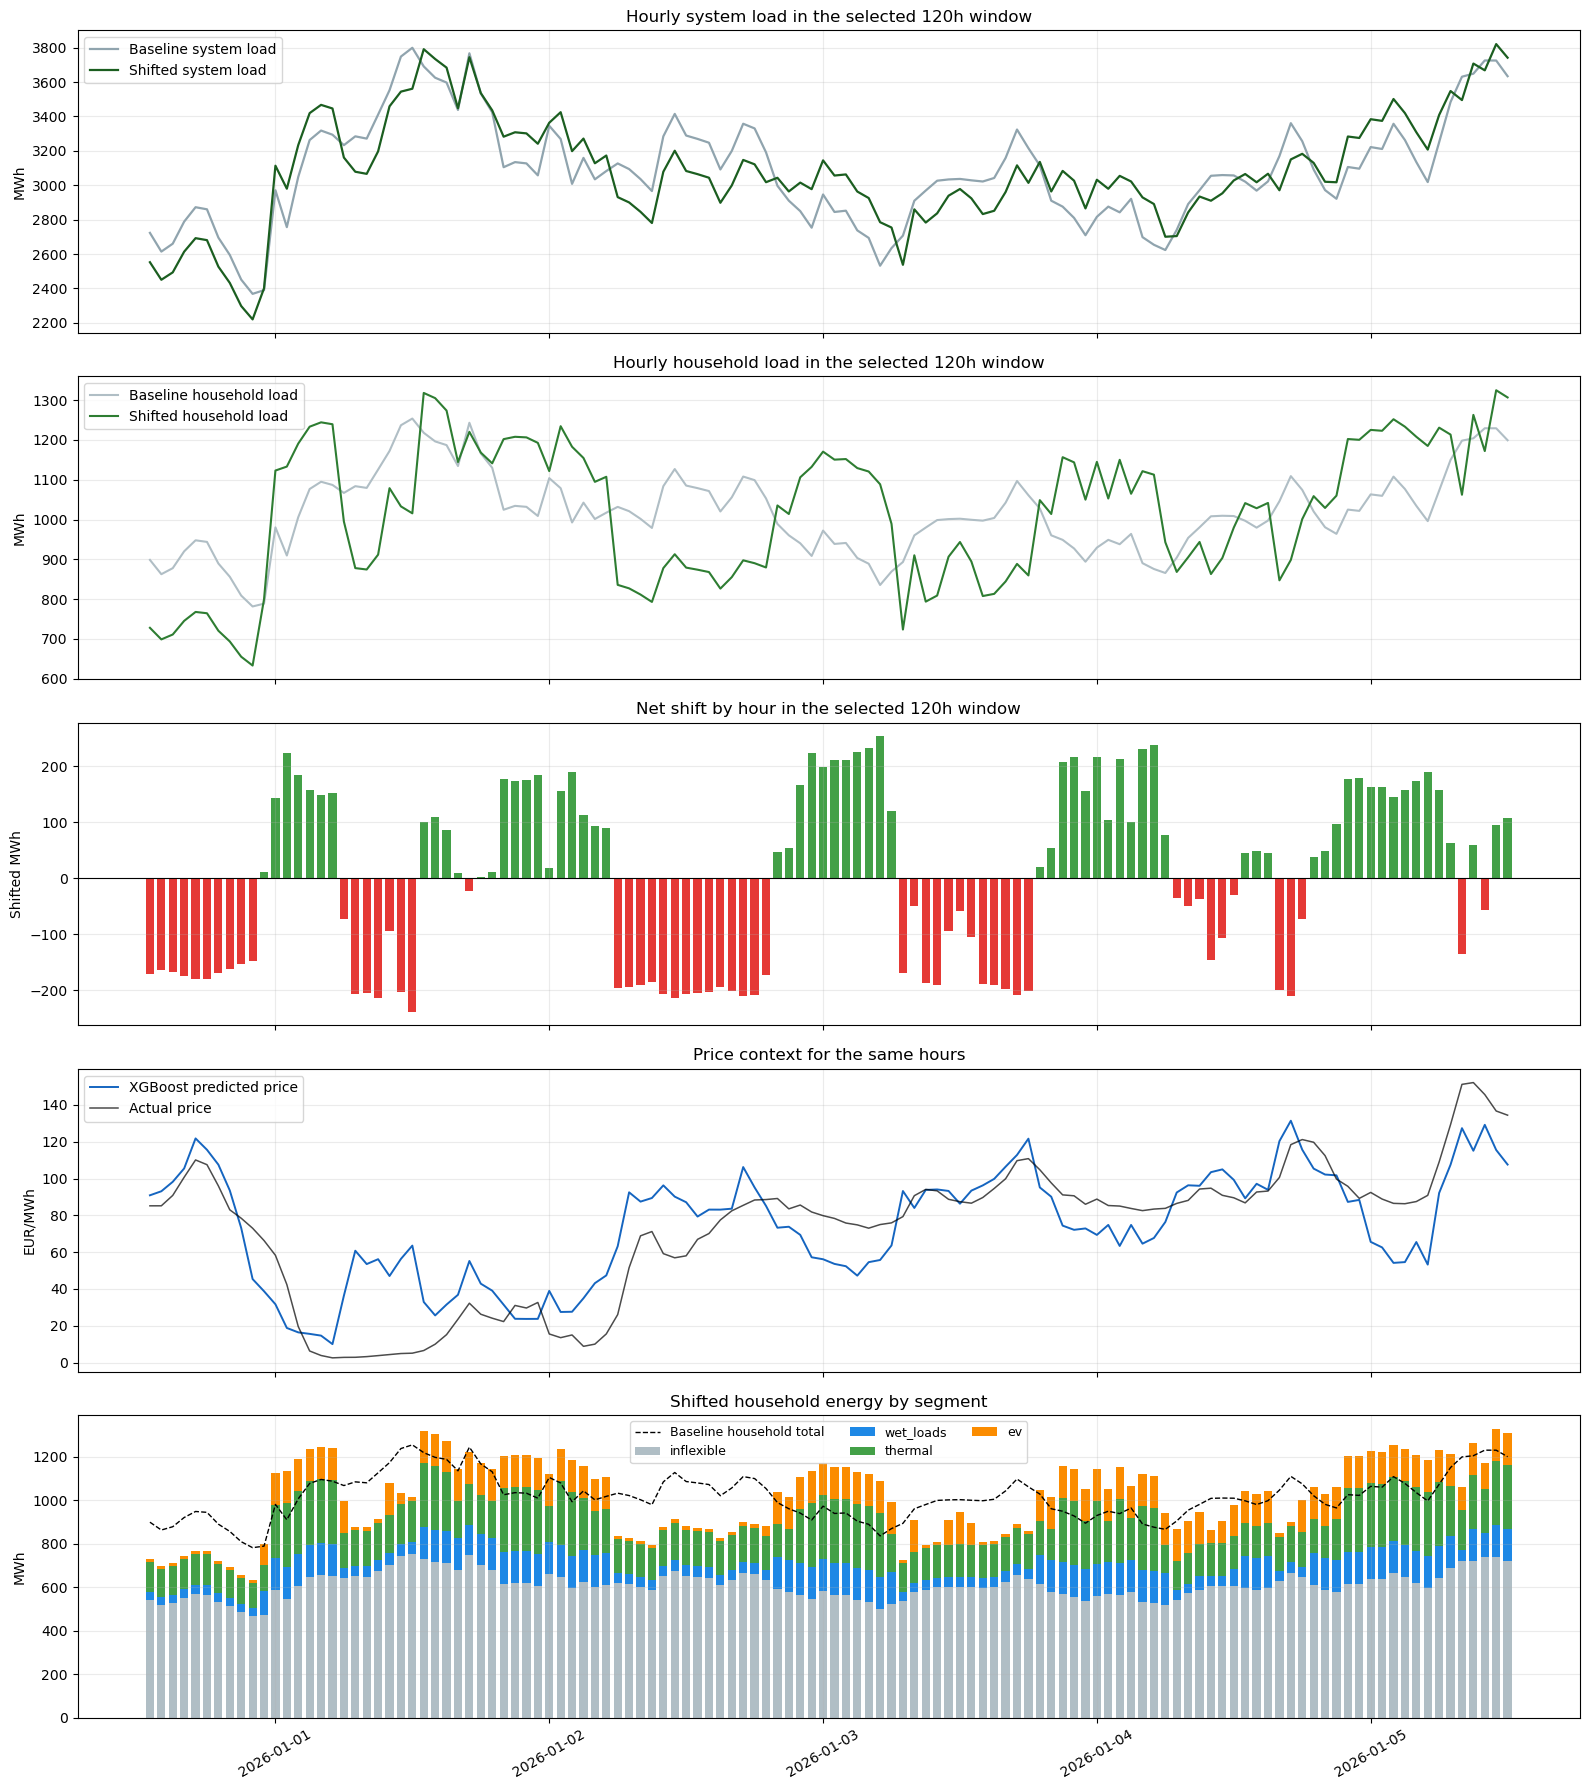

In [210]:
detail_df = prototype_df.copy()
detail_df["net_shift_mwh"] = detail_df["shifted_system_load_mwh"] - detail_df["system_load_mwh"]

fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)

axes[0].plot(detail_df["target_time"], detail_df["system_load_mwh"], label="Baseline system load", color="#90A4AE", linewidth=1.6)
axes[0].plot(detail_df["target_time"], detail_df["shifted_system_load_mwh"], label="Shifted system load", color="#1B5E20", linewidth=1.6)
axes[0].set_title("Hourly system load in the selected 120h window")
axes[0].set_ylabel("MWh")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(detail_df["target_time"], detail_df["household_load_mwh"], label="Baseline household load", color="#B0BEC5", linewidth=1.5)
axes[1].plot(detail_df["target_time"], detail_df["shifted_household_load_mwh"], label="Shifted household load", color="#2E7D32", linewidth=1.5)
axes[1].set_title("Hourly household load in the selected 120h window")
axes[1].set_ylabel("MWh")
axes[1].grid(alpha=0.25)
axes[1].legend()

bar_colors = np.where(detail_df["net_shift_mwh"] >= 0, "#43A047", "#E53935")
axes[2].bar(detail_df["target_time"], detail_df["net_shift_mwh"], color=bar_colors, width=0.03)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Net shift by hour in the selected 120h window")
axes[2].set_ylabel("Shifted MWh")
axes[2].grid(alpha=0.25)

axes[3].plot(detail_df["target_time"], detail_df["predicted"], label="XGBoost predicted price", color="#1565C0", linewidth=1.4)
axes[3].plot(detail_df["target_time"], detail_df["DayAheadPriceEUR"], label="Actual price", color="black", linewidth=1.1, alpha=0.7)
axes[3].set_title("Price context for the same hours")
axes[3].set_ylabel("EUR/MWh")
axes[3].grid(alpha=0.25)
axes[3].legend()

segment_order = list(SEGMENT_ASSUMPTIONS.keys())
stack_bottom = np.zeros(len(detail_df))
for segment in segment_order:
    shifted_col = f"{segment}_shifted_mwh"
    axes[4].bar(
        detail_df["target_time"],
        detail_df[shifted_col],
        bottom=stack_bottom,
        width=0.03,
        color=SEGMENT_COLORS.get(segment, None),
        label=segment,
    )
    stack_bottom = stack_bottom + detail_df[shifted_col].to_numpy()
axes[4].plot(
    detail_df["target_time"],
    detail_df["household_load_mwh"],
    color="black",
    linewidth=1.0,
    linestyle="--",
    label="Baseline household total",
)
axes[4].set_title("Shifted household energy by segment")
axes[4].set_ylabel("MWh")
axes[4].grid(alpha=0.25)
axes[4].legend(ncol=3, fontsize=9)

plt.xticks(rotation=30)
plt.tight_layout()


In [211]:
rolling_hour_pattern = rolling_backtest_df.copy()

annual_issue_times = daily_issue_times.tail(ANNUAL_HEATMAP_DAILY_ISSUES).reset_index(drop=True)
annual_non_overlapping_issue_times = annual_issue_times.iloc[::5].reset_index(drop=True)

annual_profiles = []

for issue_time in annual_non_overlapping_issue_times:
    annual_window_df = assemble_window_for_issue_time(
        issue_time=issue_time,
        preds=preds,
        system_load=system_load,
        household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
        segment_assumptions=SEGMENT_ASSUMPTIONS,
    )
    annual_profile_df, _ = build_shift_plan(
        annual_window_df,
        SEGMENT_ASSUMPTIONS,
        DECISION_WEIGHTS,
        historical_segment_capacity,
    )
    annual_profile_df = annual_profile_df.copy()
    annual_profile_df["issue_time"] = pd.Timestamp(issue_time)
    annual_profile_df["date"] = annual_profile_df["target_time"].dt.date
    annual_profile_df["hour"] = annual_profile_df["target_time"].dt.hour
    annual_profile_df["day_of_week"] = annual_profile_df["target_time"].dt.day_name()
    annual_profile_df["net_shift_mwh"] = annual_profile_df["shifted_system_load_mwh"] - annual_profile_df["system_load_mwh"]
    annual_profiles.append(annual_profile_df)

annual_profiles_df = pd.concat(annual_profiles, ignore_index=True)

display(
    pd.Series(
        {
            "annual_daily_issue_times_available": int(len(annual_issue_times)),
            "annual_non_overlapping_120h_windows": int(len(annual_non_overlapping_issue_times)),
            "annual_profile_hours": int(len(annual_profiles_df)),
            "annual_start": str(annual_profiles_df["target_time"].min()),
            "annual_end": str(annual_profiles_df["target_time"].max()),
        }
    ).to_frame("value")
)


,value
annual_daily_issue_times_available,365
annual_non_overlapping_120h_windows,73
annual_profile_hours,8760
annual_start,2024-12-27 13:00:00
annual_end,2026-01-01 12:00:00


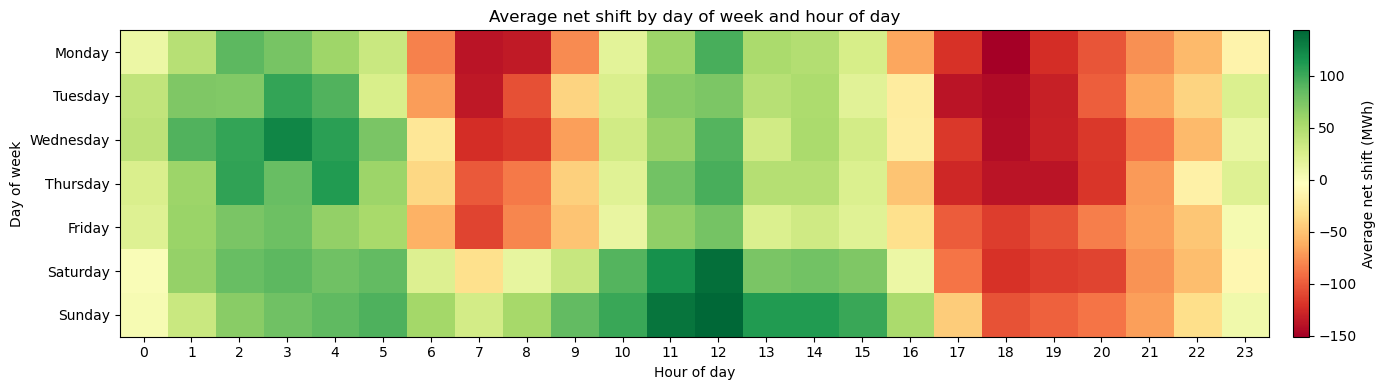

In [212]:
dow_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

net_shift_heatmap = (
    annual_profiles_df.groupby(["day_of_week", "hour"], as_index=False)["net_shift_mwh"]
    .mean()
    .assign(day_of_week=lambda df: pd.Categorical(df["day_of_week"], categories=dow_order, ordered=True))
    .sort_values(["day_of_week", "hour"])
    .pivot(index="day_of_week", columns="hour", values="net_shift_mwh")
)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(net_shift_heatmap.to_numpy(), aspect="auto", cmap="RdYlGn", interpolation="nearest")
ax.set_title("Average net shift by day of week and hour of day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week")
ax.set_xticks(np.arange(24))
ax.set_yticks(np.arange(len(net_shift_heatmap.index)))
ax.set_yticklabels(net_shift_heatmap.index.tolist())
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Average net shift (MWh)")
plt.tight_layout()


## Yearly Before/After Heatmaps

To make the heatmaps interpretable, the notebook uses a continuous non-overlapping annual sample built from `120h` windows spaced `5` days apart. That gives a clean year-like hourly panel without double-counting overlapping forecast horizons.


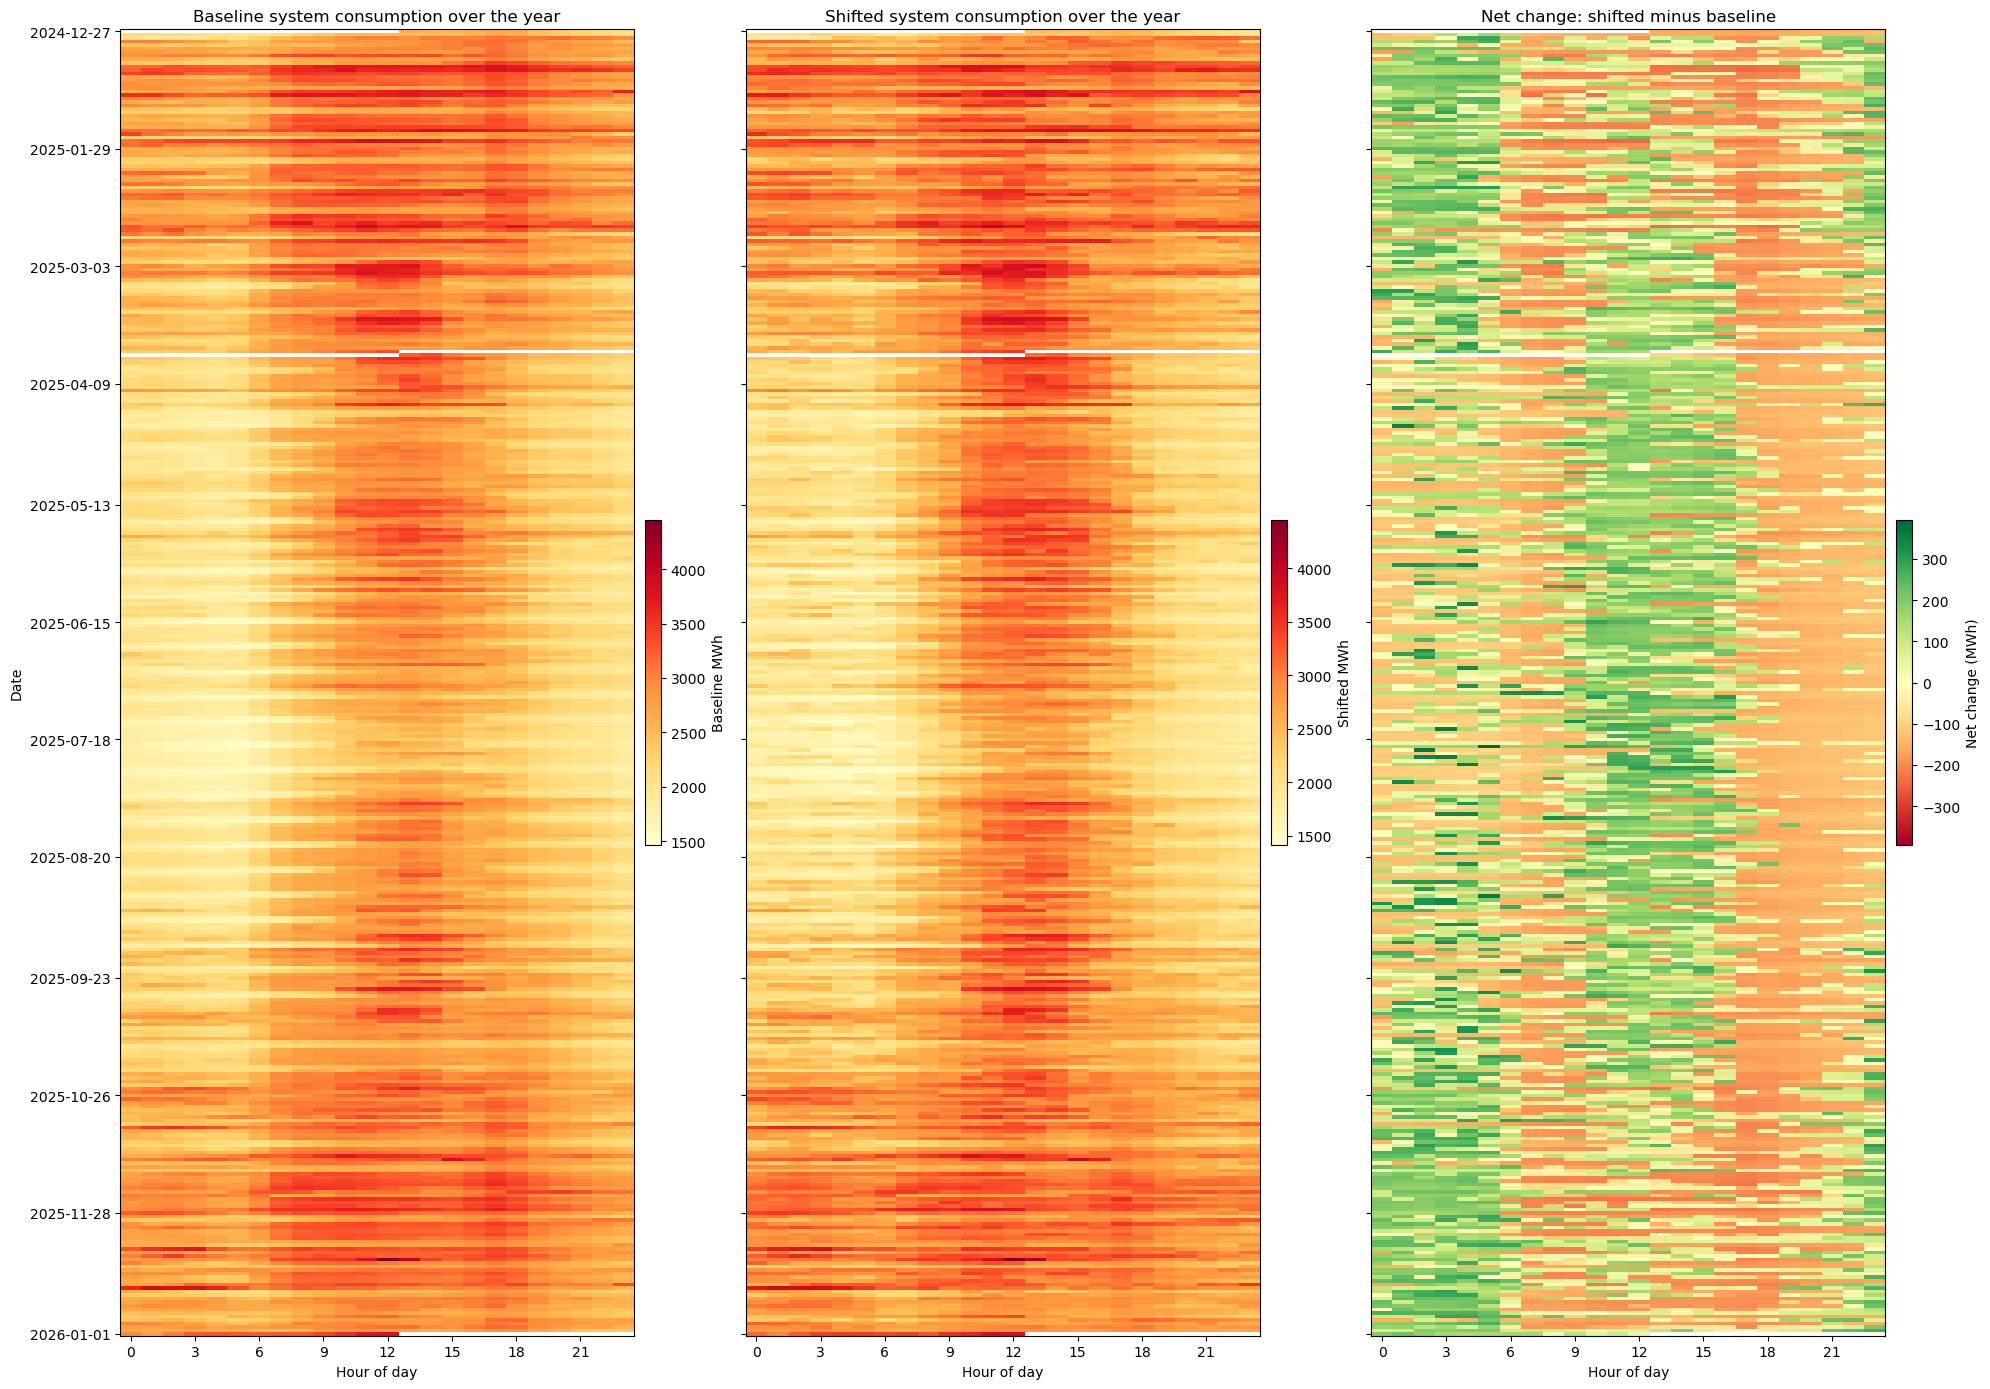

In [213]:
baseline_year_heatmap = (
    annual_profiles_df.pivot(index="date", columns="hour", values="system_load_mwh")
    .sort_index()
)
shifted_year_heatmap = (
    annual_profiles_df.pivot(index="date", columns="hour", values="shifted_system_load_mwh")
    .sort_index()
)
difference_year_heatmap = shifted_year_heatmap - baseline_year_heatmap

fig, axes = plt.subplots(1, 3, figsize=(20, 14), sharey=True)

im0 = axes[0].imshow(baseline_year_heatmap.to_numpy(), aspect="auto", cmap="YlOrRd", interpolation="nearest")
axes[0].set_title("Baseline system consumption over the year")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Date")
axes[0].set_xticks(np.arange(0, 24, 3))

im1 = axes[1].imshow(shifted_year_heatmap.to_numpy(), aspect="auto", cmap="YlOrRd", interpolation="nearest")
axes[1].set_title("Shifted system consumption over the year")
axes[1].set_xlabel("Hour of day")
axes[1].set_xticks(np.arange(0, 24, 3))

max_abs_diff = np.nanmax(np.abs(difference_year_heatmap.to_numpy()))
im2 = axes[2].imshow(
    difference_year_heatmap.to_numpy(),
    aspect="auto",
    cmap="RdYlGn",
    interpolation="nearest",
    vmin=-max_abs_diff,
    vmax=max_abs_diff,
)
axes[2].set_title("Net change: shifted minus baseline")
axes[2].set_xlabel("Hour of day")
axes[2].set_xticks(np.arange(0, 24, 3))

date_tick_positions = np.linspace(0, len(baseline_year_heatmap.index) - 1, 12, dtype=int)
axes[0].set_yticks(date_tick_positions)
axes[0].set_yticklabels([str(baseline_year_heatmap.index[i]) for i in date_tick_positions])

cbar0 = fig.colorbar(im0, ax=axes[0], fraction=0.03, pad=0.02)
cbar0.set_label("Baseline MWh")
cbar1 = fig.colorbar(im1, ax=axes[1], fraction=0.03, pad=0.02)
cbar1.set_label("Shifted MWh")
cbar2 = fig.colorbar(im2, ax=axes[2], fraction=0.03, pad=0.02)
cbar2.set_label("Net change (MWh)")

plt.tight_layout()


## 20-Day Segment Net Shift Timeline

This view uses `4` non-overlapping `120h` windows to create a continuous `20` day sample. Bars below zero show energy moved away from an hour, while bars above zero show energy added to that hour.


,value
plot_days,20
plot_hours,480
plot_start,2025-12-12 13:00:00
plot_end,2026-01-01 12:00:00


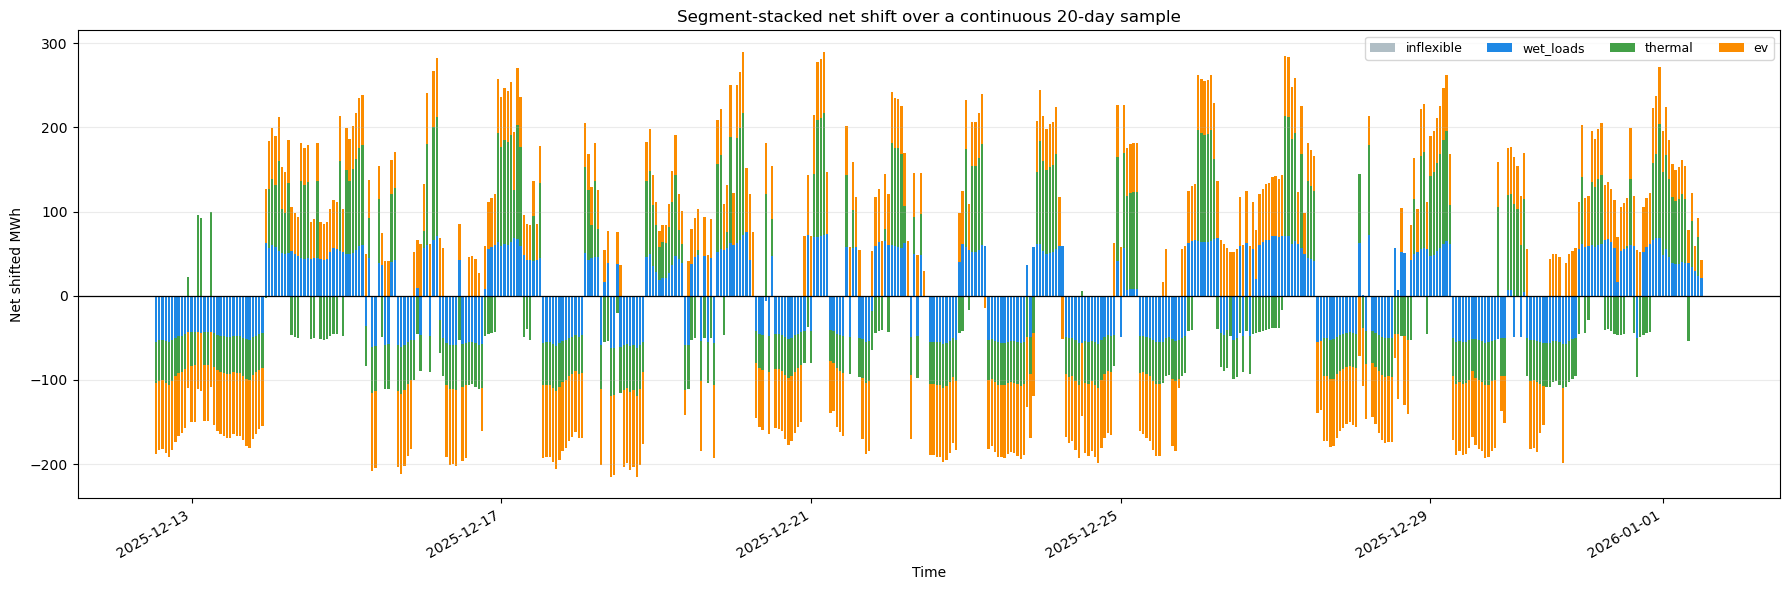

In [214]:
plot_20d_issue_times = annual_non_overlapping_issue_times.tail(4).reset_index(drop=True)

segment_net_shift_profiles = []

for issue_time in plot_20d_issue_times:
    plot_window_df = assemble_window_for_issue_time(
        issue_time=issue_time,
        preds=preds,
        system_load=system_load,
        household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
        segment_assumptions=SEGMENT_ASSUMPTIONS,
    )
    plot_profile_df, _ = build_shift_plan(
        plot_window_df,
        SEGMENT_ASSUMPTIONS,
        DECISION_WEIGHTS,
        historical_segment_capacity,
    )
    plot_profile_df = plot_profile_df.copy()
    plot_profile_df["issue_time"] = pd.Timestamp(issue_time)
    segment_net_shift_profiles.append(plot_profile_df)

net_shift_20d_df = (
    pd.concat(segment_net_shift_profiles, ignore_index=True)
    .sort_values("target_time")
    .drop_duplicates(subset=["target_time"], keep="first")
    .reset_index(drop=True)
)

segment_order = list(SEGMENT_ASSUMPTIONS.keys())
for segment in segment_order:
    baseline_col = f"{segment}_baseline_mwh"
    shifted_col = f"{segment}_shifted_mwh"
    net_col = f"{segment}_net_shift_mwh"
    net_shift_20d_df[net_col] = net_shift_20d_df[shifted_col] - net_shift_20d_df[baseline_col]

display(
    pd.Series(
        {
            "plot_days": int(len(net_shift_20d_df) / 24),
            "plot_hours": int(len(net_shift_20d_df)),
            "plot_start": str(net_shift_20d_df["target_time"].min()),
            "plot_end": str(net_shift_20d_df["target_time"].max()),
        }
    ).to_frame("value")
)

fig, ax = plt.subplots(figsize=(18, 6))

positive_bottom = np.zeros(len(net_shift_20d_df))
negative_bottom = np.zeros(len(net_shift_20d_df))

for segment in segment_order:
    net_col = f"{segment}_net_shift_mwh"
    values = net_shift_20d_df[net_col].to_numpy(dtype=float)
    positive_values = np.clip(values, 0, None)
    negative_values = np.clip(values, None, 0)

    ax.bar(
        net_shift_20d_df["target_time"],
        positive_values,
        bottom=positive_bottom,
        width=0.03,
        color=SEGMENT_COLORS.get(segment, None),
        label=segment,
    )
    ax.bar(
        net_shift_20d_df["target_time"],
        negative_values,
        bottom=negative_bottom,
        width=0.03,
        color=SEGMENT_COLORS.get(segment, None),
    )

    positive_bottom = positive_bottom + positive_values
    negative_bottom = negative_bottom + negative_values

ax.axhline(0, color="black", linewidth=0.9)
ax.set_title("Segment-stacked net shift over a continuous 20-day sample")
ax.set_xlabel("Time")
ax.set_ylabel("Net shifted MWh")
ax.grid(axis="y", alpha=0.25)
ax.legend(ncol=4, fontsize=9)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()


## Next Prototype Steps

This version now includes:
- one fully inspectable 120-hour prototype window
- explicit shifted MWh and shifted-share metrics
- a daily rolling backtest sample
- a non-overlapping horizon summary for clean aggregate consumption shares

The next improvements should be:

1. replace the heuristic with an optimization model
2. use horizon-specific XGBoost residual distributions for forecast uncertainty
3. make EV and thermal segments deadline-based instead of using one generic shift rule
4. add formal grid stress metrics across the full sample
5. compare multiple scenario settings for household shares and flexibility assumptions
